<h1 align="center">3D Heart Segmentation from Cardiac CT</h1>

<p align="center">
  <b>An end-to-end 3D deep learning pipeline utilizing PyTorch and MONAI</b>
</p>

---

### 🛠️ Ground Truth Generation & Preprocessing
To address the lack of manual voxel-level annotations, the pipeline utilizes the resource-intensive **TotalSegmentator** tool (`--roi_subset heart`) to automatically generate pseudo-label ground truths. Simultaneously, a custom script parses XML files containing manual calcium point coordinates. These coordinates are mapped to the DICOM physical space using `SimpleITK`, and dense 3D polygons are generated via OpenCV to establish precise coronary calcium masks across the 50-patient cohort.

The raw CT volumes are first passed through a standard `MONAI` preprocessing sequence:
* **Cardiac Windowing:** Hounsfield Units (HU) are clipped between `-160` and `240` to isolate cardiovascular soft tissue, followed by min-max normalization to a `[0.0, 1.0]` tensor range.
* **Spatial Resampling:** Volumes are uniformly resampled to an isotropic voxel spacing of `1.5 x 1.5 x 1.5 mm³`.

### 💡 Solving the SegResNet Calcium Exclusion Paradox
During initial testing, a classic medical imaging paradox emerged: the higher-capacity **SegResNet** achieved exceptional anatomical precision but severely failed its primary clinical objective, capturing only **~15.94%** of the coronary calcium. Its residual connections allowed it to over-fit to the exact 'healthy' boundary of the myocardium, systematically excluding the calcium deposits sitting just outside on the epicardial surface.

To solve this natively without post-processing, a custom **`DilateLabeld`** map transform was engineered directly into the MONAI data-loading pipeline:
* It applies a highly efficient **3D Max Pooling operation** (`kernel_size=5`, `stride=1`, `padding=2`) to the ground-truth heart labels *after* physical resampling.
* This morphological dilation mathematically expands the target boundary outward by exactly **3.0 millimeters** in all directions.
* By training on these artificially dilated labels, the SegResNet is forced to learn a clinical "safety buffer," skyrocketing its **Calcium Inclusion metric to 82.75%** while maintaining a state-of-the-art Dice Score.

### 🔄 Stratified Data Split & Patch-Based Transforms
To ensure robust model evaluation and prevent data leakage, the 50-patient dataset was rigorously partitioned into **34 Training, 8 Validation, and 8 Testing** volumes. 

Because standard 3D CT volumes exceed standard GPU memory constraints, the training pipeline relies on dynamic patch extraction and on-the-fly augmentation:
* **Patch Extraction:** Random `96 x 96 x 96` spatial tensors are cropped from the full volumes during the training loop.
* **Spatial & Noise Augmentations:** To mitigate overfitting on the relatively small patient cohort, these patches are heavily augmented using MONAI transforms, including `RandAffined` (rotation, translation, scaling), `RandFlipd`, and `RandGaussianNoised`.

### ⚖️ Architecture & Handling Class Imbalance
An Exploratory Data Analysis (EDA) on the extracted patches revealed a severe class imbalance: **~73.31% background, ~26.65% heart**, and a highly sparse **~0.04% calcium**. 
To combat this, the training strategy utilizes a **Dice Loss** function to optimize for spatial overlap rather than raw voxel-wise accuracy. The baseline model is a lightweight 3D U-Net, which is optimized alongside a higher-capacity SegResNet architecture to evaluate performance trade-offs.

### 🧠 Justification for Model Choice
For the rapid heart segmentation task, **SegResNet** was selected as the primary architecture due to its exceptional balance of state-of-the-art spatial precision and ultra-fast inference. While the baseline 3D U-Net delivered sub-second execution (0.0976 sec/vol) and naturally high calcium inclusion, it plateaued at an anatomical Dice Score of 0.8925. SegResNet overcomes these spatial limitations by integrating residual blocks within its encoder-decoder framework. This design mitigates the vanishing gradient problem and empowers the network to extract deeper, richer volumetric features, effectively navigating the severe class imbalance (~73.31% background, ~26.65% heart, and the highly sparse ~0.04% calcium). 

Coupled with the custom morphological dilation transform to secure the peripheral pathology (boosting calcium inclusion to a viable 82.75%), this architectural refinement allowed SegResNet to achieve an outstanding **Test Dice Score of 0.9440**. Remarkably, it achieved this highest-tier accuracy while running marginally faster than the baseline at **0.0955 seconds per volume**—delivering a massive **351x speedup** over the computationally expensive TotalSegmentator pipeline without compromising diagnostic reliability.

### 📊 Evaluation & Results
The models were evaluated on the **8 unseen test volumes** against the TotalSegmentator baseline. Beyond standard anatomical overlap (Dice Score) and inference speed, the pipeline uniquely evaluates **calcium inclusion**—a domain-specific metric (`evaluate_calcium_inclusion`) that calculates the percentage of true calcium voxels successfully captured within the predicted heart volume. This ensures the segmentation remains diagnostically viable for downstream coronary calcium scoring.

| Model | Test Dice Score | Inference Time (sec/vol) | Speedup vs TS Baseline | Avg Calcium Included in Heart Mask |
| :--- | :---: | :---: | :---: | :---: |
| **TotalSegmentator** *(Baseline)* | N/A *(Ground Truth)* | ~33.5502 | 1x | **100%** *(Reference)* |
| **Baseline 3D U-Net** | 0.8925 | 0.0976 | **~344x** | **99.90%** |
| **SegResNet** | **0.9440** | **0.0955** | **~351x** | **82.75%** |

In [25]:
# Install required packages
!pip install -q monai SimpleITK nibabel TotalSegmentator scikit-learn matplotlib

In [26]:
# ==================================
#       SETUP & IMPORTS
# ==================================
import os
import glob
import time
import shutil
import random
import subprocess
import plistlib
import cv2 
import numpy as np
import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

from monai.data import Dataset, DataLoader, list_data_collate
from monai.networks.nets import UNet, SegResNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, 
    ScaleIntensityRanged, CropForegroundd, SpatialPadd, RandCropByPosNegLabeld, 
    RandAffined, RandFlipd, RandRotate90d, RandGaussianNoised, ToTensord
)

In [27]:
# ==============================================================================
#   CONFIGURATION & PATHS
# ==============================================================================
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

XML_BASE_DIR = "/kaggle/input/datasets/chayondas/coca-data/COCA_Dataset/Gated_release_final/calcium_xml/"
DICOM_BASE_DIR = "/kaggle/input/datasets/chayondas/coca-data/COCA_Dataset/Gated_release_final/patient/"

NIFTI_IMG_DIR = "/kaggle/working/nifti_images"
NIFTI_MASK_DIR = "/kaggle/working/nifti_masks"
CALCIUM_MASKS_DIR = "/kaggle/working/converted_calcium_niftis/"

os.makedirs(NIFTI_IMG_DIR, exist_ok=True)
os.makedirs(NIFTI_MASK_DIR, exist_ok=True)

NUM_SCANS_TO_PROCESS = 50 
EPOCHS = 200
SPATIAL_SIZE = (96, 96, 96)

Using device: cuda:0


In [28]:
# ==============================================================================
#  COMBINED SEARCH & CONVERSION (GUARANTEES 50 VALID SCANS) For Calcium Masks
# ==============================================================================
print(f"\n--- Hunting for Exactly {NUM_SCANS_TO_PROCESS} Patients with Valid Calcium ---")

if os.path.exists(CALCIUM_MASKS_DIR):
    shutil.rmtree(CALCIUM_MASKS_DIR)
os.makedirs(CALCIUM_MASKS_DIR, exist_ok=True)

all_xml_files = sorted(glob.glob(os.path.join(XML_BASE_DIR, "*.xml")))
TARGET_PATIENTS = []

for xml_path in all_xml_files:
    patient_id = os.path.basename(xml_path).split('.')[0]
    
    if patient_id == "12":
        continue

    patient_dicom_dir = os.path.join(DICOM_BASE_DIR, patient_id)
    dicom_series_dir = None
    
    if os.path.exists(patient_dicom_dir):
        for root, dirs, files in os.walk(patient_dicom_dir):
            if len(files) > 0: 
                dicom_series_dir = root
                break
                
    if not dicom_series_dir:
        continue
            
    try:
        reader = sitk.ImageSeriesReader()
        dicom_names = reader.GetGDCMSeriesFileNames(dicom_series_dir)
        if not dicom_names: continue
            
        reader.SetFileNames(dicom_names)
        original_ct = reader.Execute()
        mask_array = np.zeros(original_ct.GetSize()[::-1], dtype=np.uint8) 
        
        with open(xml_path, 'rb') as f:
            plist_data = plistlib.load(f)
            
        images = plist_data.get('Images', [])
        for image_dict in images:
            z_index = image_dict.get('ImageIndex')
            if z_index is None or z_index >= mask_array.shape[0]: continue
                
            rois = image_dict.get('ROIs', [])
            for roi in rois:
                points = []
                raw_px = roi.get('Point_px', [])
                raw_mm = roi.get('Point_mm', [])
                
                points_to_parse = raw_px if len(raw_px) > 0 else raw_mm
                is_physical = (len(raw_px) == 0 and len(raw_mm) > 0)
                
                for pt_str in points_to_parse:
                    coords = [float(c) for c in pt_str.strip('() {}').split(',')]
                    if is_physical and len(coords) == 3:
                        idx = original_ct.TransformPhysicalPointToContinuousIndex((coords[0], coords[1], coords[2]))
                        points.append([int(round(idx[0])), int(round(idx[1]))])
                    else:
                        points.append([int(round(coords[0])), int(round(coords[1]))])
                
                if len(points) > 2:
                    pts_array = np.array(points, np.int32).reshape((-1, 1, 2))
                    cv2.fillPoly(mask_array[z_index], [pts_array], 1)
                    
        total_voxels = mask_array.sum()
        if total_voxels > 0:
            out_mask_path = os.path.join(CALCIUM_MASKS_DIR, f"{patient_id}.nii.gz")
            calcium_mask_sitk = sitk.GetImageFromArray(mask_array)
            calcium_mask_sitk.CopyInformation(original_ct)
            sitk.WriteImage(calcium_mask_sitk, out_mask_path)
            
            TARGET_PATIENTS.append(patient_id)
        
            
        if len(TARGET_PATIENTS) >= NUM_SCANS_TO_PROCESS:
            break
            
    except Exception as e:
        continue

print(f"\n--- Successfully locked in {len(TARGET_PATIENTS)} patients with confirmed calcium! ---")


--- Hunting for Exactly 50 Patients with Valid Calcium ---

--- Successfully locked in 50 patients with confirmed calcium! ---


In [29]:
# ==============================================================================
#         DICOM TO NIFTI CONVERSION & GROUND TRUTH GENERATION
# ==============================================================================
def is_valid_nifti(filepath):
    if not os.path.exists(filepath) or os.path.isdir(filepath): return False
    try: nib.load(filepath); return True
    except: return False

print(f"\n--- Starting DICOM to NIfTI Conversion & TotalSegmentator ---")
nifti_files = []

for patient_id in TARGET_PATIENTS:
    patient_dir = os.path.join(DICOM_BASE_DIR, patient_id)
    dicom_series_dir = None
    for root, dirs, files in os.walk(patient_dir):
        if len(files) > 0: 
            dicom_series_dir = root
            break
            
    out_nifti_path = os.path.join(NIFTI_IMG_DIR, f"patient_{patient_id}.nii.gz")
    
    if not is_valid_nifti(out_nifti_path):
        if os.path.exists(out_nifti_path):
            if os.path.isdir(out_nifti_path): shutil.rmtree(out_nifti_path)
            else: os.remove(out_nifti_path)
        reader = sitk.ImageSeriesReader()
        reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_series_dir))
        sitk.WriteImage(reader.Execute(), out_nifti_path)
    
    nifti_files.append(out_nifti_path)

mask_files = []
for nifti_img in nifti_files:
    patient_id = os.path.basename(nifti_img).split('.')[0].replace("patient_", "") 
    patient_mask_folder = os.path.join(NIFTI_MASK_DIR, patient_id)
    out_mask_path = os.path.join(patient_mask_folder, "heart.nii.gz") 
    
    if not is_valid_nifti(out_mask_path):
        if os.path.exists(patient_mask_folder): shutil.rmtree(patient_mask_folder)
        os.system(f"TotalSegmentator -i {nifti_img} -o {patient_mask_folder} --roi_subset heart > /dev/null 2>&1")
    mask_files.append(out_mask_path)

valid_data_dicts = []
for nifti_img, mask_path in zip(nifti_files, mask_files):
    if is_valid_nifti(mask_path):
        patient_id = os.path.basename(nifti_img).split('.')[0].replace("patient_", "")
        calc_path = os.path.join(CALCIUM_MASKS_DIR, f"{patient_id}.nii.gz")
        
        data_dict = {"image": nifti_img, "label": mask_path}
        if os.path.exists(calc_path):
            data_dict["calcium_mask"] = calc_path
            
        valid_data_dicts.append(data_dict)

print(f"Successfully prepared {len(valid_data_dicts)} completely valid image-mask pairs.")


--- Starting DICOM to NIfTI Conversion & TotalSegmentator ---
Successfully prepared 50 completely valid image-mask pairs.


In [30]:
# ==============================================================================
#              STRATIFIED DATA SPLIT & PATCH-BASED TRANSFORMS
# ==============================================================================
import torch
import torch.nn.functional as F
import random
from monai.transforms import MapTransform, Compose, LoadImaged, EnsureChannelFirstd, Spacingd, ScaleIntensityRanged, CropForegroundd, SpatialPadd, RandCropByPosNegLabeld, RandAffined, RandFlipd, RandRotate90d, RandGaussianNoised, ToTensord
from monai.data import Dataset, DataLoader, list_data_collate

# DEFINE THE CUSTOM DILATION TRANSFORM ---
class DilateLabeld(MapTransform):
    def __init__(self, keys, kernel_size=5, allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.kernel_size = kernel_size

    def __call__(self, data):
        d = dict(data)
        for key in self.key_iterator(d):
            label = d[key]
            # Ensure it is a tensor (it will be, since LoadImaged ran first)
            if not isinstance(label, torch.Tensor):
                label = torch.tensor(label)
            
            # max_pool3d needs a batch dim: [1, Channel, D, H, W]
            label = label.unsqueeze(0) 
            dilated = F.max_pool3d(label.float(), kernel_size=self.kernel_size, stride=1, padding=self.kernel_size//2)
            d[key] = dilated.squeeze(0).to(d[key].dtype)
        return d
# -----------------------------------------------

positive_scans = [d for d in valid_data_dicts if "calcium_mask" in d]

print(f"\n--- Stratification Info ---")
print(f"Total Valid Scans Available: {len(positive_scans)}")

random.seed(42)
random.shuffle(positive_scans)

test_files = positive_scans[:8]
val_files = positive_scans[8:16]
train_files = positive_scans[16:] 

print(f"Exact Split sizes -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")


train_transforms = Compose([
    LoadImaged(keys=["image", "label", "calcium_mask"], allow_missing_keys=True),
    EnsureChannelFirstd(keys=["image", "label", "calcium_mask"], allow_missing_keys=True),
    Spacingd(keys=["image", "label", "calcium_mask"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest", "nearest"), allow_missing_keys=True),
    
    # Executed safely here as a Tensor: Expands the mask by 3mm
    DilateLabeld(keys=["label"], kernel_size=5),
    
    ScaleIntensityRanged(keys=["image"], a_min=-160, a_max=240, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label", "calcium_mask"], source_key="image", allow_missing_keys=True),
    SpatialPadd(keys=["image", "label", "calcium_mask"], spatial_size=SPATIAL_SIZE, allow_missing_keys=True), 
    RandCropByPosNegLabeld(
        keys=["image", "label", "calcium_mask"],
        label_key="label",
        spatial_size=SPATIAL_SIZE,
        pos=1, neg=1,
        num_samples=2, 
        image_key="image",
        image_threshold=0,
        allow_missing_keys=True
    ),
    RandAffined(keys=["image", "label", "calcium_mask"], prob=0.5, translate_range=10, rotate_range=0.1, mode=("bilinear", "nearest", "nearest"), allow_missing_keys=True),
    RandFlipd(keys=["image", "label", "calcium_mask"], spatial_axis=[0], prob=0.5, allow_missing_keys=True),
    RandRotate90d(keys=["image", "label", "calcium_mask"], prob=0.5, spatial_axes=(0, 1), allow_missing_keys=True),
    RandGaussianNoised(keys=["image"], prob=0.1, mean=0.0, std=0.1),
    ToTensord(keys=["image", "label", "calcium_mask"], allow_missing_keys=True),
])

# --- 3. INJECT INTO VALIDATION PIPELINE ---
val_transforms = Compose([
    LoadImaged(keys=["image", "label", "calcium_mask"], allow_missing_keys=True),
    EnsureChannelFirstd(keys=["image", "label", "calcium_mask"], allow_missing_keys=True),
    Spacingd(keys=["image", "label", "calcium_mask"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest", "nearest"), allow_missing_keys=True),
    
    # Must also dilate validation labels so Dice scores are calculated against the same expanded boundary
    DilateLabeld(keys=["label"], kernel_size=5),
    
    ScaleIntensityRanged(keys=["image"], a_min=-160, a_max=240, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label", "calcium_mask"], source_key="image", allow_missing_keys=True),
    ToTensord(keys=["image", "label", "calcium_mask"], allow_missing_keys=True),
])

train_loader = DataLoader(Dataset(data=train_files, transform=train_transforms), batch_size=4, shuffle=True, num_workers=2, collate_fn=list_data_collate)
val_loader = DataLoader(Dataset(data=val_files, transform=val_transforms), batch_size=1, shuffle=False, num_workers=2)
test_loader = DataLoader(Dataset(data=test_files, transform=val_transforms), batch_size=1, shuffle=False, num_workers=2)


--- Stratification Info ---
Total Valid Scans Available: 50
Exact Split sizes -> Train: 34, Val: 8, Test: 8



--- DATASET STATISTICS & EDA ---
Batch Image Shape: torch.Size([8, 1, 96, 96, 96]) (Patched)
Intensity Range:   Min: 0.00, Max: 1.00

--- Class Imbalance Analysis ---
Background Voxels: 5188760.0 (73.31%)
Heart Voxels:      1886511.0 (26.65%)
Calcium Voxels:    2617.0 (0.0370%)


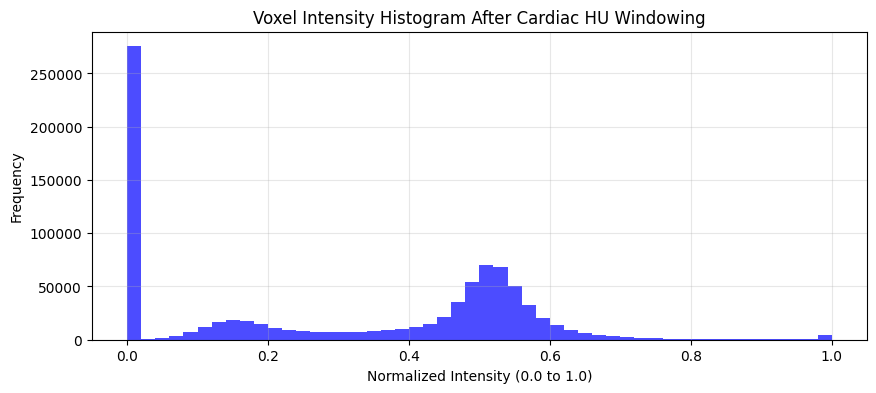

In [31]:
# ==============================================================================
#                      DATASET STATISTICS & EDA
# ==============================================================================
print("\n========================================================")
print("--- DATASET STATISTICS & EDA ---")
print("========================================================")

if len(train_loader) > 0:
    eda_data = next(iter(train_loader))
    images, labels = eda_data["image"], eda_data["label"]

    print(f"Batch Image Shape: {images.shape} (Patched)")
    print(f"Intensity Range:   Min: {images.min().item():.2f}, Max: {images.max().item():.2f}")

    heart_voxels = labels.sum().item()
    total_voxels = torch.numel(labels)

    has_calcium = "calcium_mask" in eda_data and eda_data["calcium_mask"].numel() > 0
    if has_calcium:
        calcium_masks = eda_data["calcium_mask"]
        calcium_voxels = calcium_masks.sum().item()
    else:
        calcium_voxels = 0

    background_voxels = total_voxels - heart_voxels - calcium_voxels
    heart_percentage = (heart_voxels / total_voxels) * 100
    calcium_percentage = (calcium_voxels / total_voxels) * 100
    background_percentage = (background_voxels / total_voxels) * 100

    print(f"\n--- Class Imbalance Analysis ---")
    print(f"Background Voxels: {background_voxels} ({background_percentage:.2f}%)")
    print(f"Heart Voxels:      {heart_voxels} ({heart_percentage:.2f}%)")

    if has_calcium:
        print(f"Calcium Voxels:    {calcium_voxels} ({calcium_percentage:.4f}%)")
    else:
        print("Calcium Voxels:    0 (No calcium present in this specific batch)")

    plt.figure(figsize=(10, 4))
    plt.hist(images[0, 0].cpu().numpy().flatten(), bins=50, color='blue', alpha=0.7)
    plt.title("Voxel Intensity Histogram After Cardiac HU Windowing")
    plt.xlabel("Normalized Intensity (0.0 to 1.0)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

In [32]:
# ==============================================================================
#                      TRAINING & EVALUATION FUNCTIONS
# ==============================================================================
def train_model(model, save_path, epochs=EPOCHS):
    print("\n--- Starting Training & Validation ---")
    loss_function = DiceLoss(to_onehot_y=False, sigmoid=True)
    optimizer = torch.optim.Adam(model.parameters(), 1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    
    best_metric = -1
    best_metric_epoch = -1
    val_interval = 5 
    
    epoch_loss_values = []
    val_metric_values = []
    val_metric_epochs = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_data in train_loader:
            inputs, labels = batch_data["image"].to(DEVICE), batch_data["label"].to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        avg_loss = epoch_loss / len(train_loader)
        epoch_loss_values.append(avg_loss)
        
        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_outputs = sliding_window_inference(val_data["image"].to(DEVICE), SPATIAL_SIZE, 2, model)
                    val_preds = (torch.sigmoid(val_outputs) > 0.5).float()
                    dice_metric(y_pred=val_preds, y=val_data["label"].to(DEVICE))

                metric = dice_metric.aggregate().item()
                dice_metric.reset() 
                val_metric_values.append(metric)
                val_metric_epochs.append(epoch + 1)

                print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}, Val Dice: {metric:.4f}, LR: {current_lr:.6f}")

                if metric > best_metric:
                    best_metric = metric
                    best_metric_epoch = epoch + 1
                    save_weights = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
                    torch.save(save_weights, save_path)
                    print(f"  🌟 New Best Model! Saved at epoch {best_metric_epoch}")
        else:
            if epoch == 0 or (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}, LR: {current_lr:.6f}")
    
    print(f"\nTraining Complete! Best Val Dice: {best_metric:.4f} at epoch {best_metric_epoch}")
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Training Loss per Epoch", fontsize=14)
    plt.plot(range(1, epochs + 1), epoch_loss_values, label="Train Loss", color="red")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.title("Validation Dice Score", fontsize=14)
    plt.plot(val_metric_epochs, val_metric_values, label="Val Dice", color="green", marker='o')
    plt.axhline(y=0.85, color='orange', linestyle='--', label="0.85 Target")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return best_metric

def evaluate_calcium_inclusion(segresnet_pred, calcium_mask):
    pred_bool = segresnet_pred > 0
    calc_bool = calcium_mask > 0
    total_calcium_voxels = calc_bool.sum().item()
    
    if total_calcium_voxels == 0:
        return None 
        
    intersection = pred_bool & calc_bool
    calcium_inside_heart = intersection.sum().item()
    return calcium_inside_heart / total_calcium_voxels

def evaluate_and_visualize(model, weights_path, model_name):
    weights = torch.load(weights_path, map_location=DEVICE, weights_only=True)
    if isinstance(model, nn.DataParallel): model.module.load_state_dict(weights)
    else: model.load_state_dict(weights)
    
    model.eval()
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    inference_times = []
    calcium_inclusion_scores = []
    
    with torch.no_grad():
        for test_data in test_loader:
            inputs, labels = test_data["image"].to(DEVICE), test_data["label"].to(DEVICE)
            start_time = time.time()
            
            outputs = sliding_window_inference(inputs, SPATIAL_SIZE, 2, model)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            
            inference_times.append(time.time() - start_time)
            dice_metric(y_pred=preds, y=labels)

            if "calcium_mask" in test_data and test_data["calcium_mask"].numel() > 0:
                calc_mask = test_data["calcium_mask"].to(DEVICE)
                inclusion_score = evaluate_calcium_inclusion(preds, calc_mask)
                if inclusion_score is not None:
                    calcium_inclusion_scores.append(inclusion_score)
            
    final_dice = dice_metric.aggregate().item()
    avg_time = np.mean(inference_times)
    
    print(f"\n--- {model_name} Test Results ---")
    print(f"Test Dice Score: {final_dice:.4f}")
    print(f"Inference Time:  {avg_time:.4f} sec/volume")

    if calcium_inclusion_scores:
        avg_inclusion = np.mean(calcium_inclusion_scores) * 100
        total_calc_scans = len(calcium_inclusion_scores)
        
        print(f"Avg Calcium Included in Heart Mask: {avg_inclusion:.2f}%")
    else:
        print("No calcium masks found in this test set.")
    print("\n")
    
    vis_data = next(iter(test_loader))
    with torch.no_grad():
        vis_outputs = sliding_window_inference(vis_data["image"].to(DEVICE), SPATIAL_SIZE, 2, model)
        vis_pred = (torch.sigmoid(vis_outputs) > 0.5).float()
        
    img_np = vis_data["image"][0, 0].cpu().numpy()    
    gt_np = vis_data["label"][0, 0].cpu().numpy()      
    pred_np = vis_pred[0, 0].cpu().numpy()    

    z_sums = gt_np.sum(axis=(0, 1))
    slice_idx = np.argmax(z_sums) if z_sums.max() > 0 else gt_np.shape[2] // 2

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Original CT (Slice {slice_idx})")
    plt.imshow(img_np[:, :, slice_idx], cmap="gray")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(img_np[:, :, slice_idx], cmap="gray")
    plt.imshow(gt_np[:, :, slice_idx], cmap="Reds", alpha=0.5) 
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"{model_name} Prediction")
    plt.imshow(img_np[:, :, slice_idx], cmap="gray")
    plt.imshow(pred_np[:, :, slice_idx], cmap="Greens", alpha=0.5)
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
    return final_dice, avg_time


--- LIGHTWEIGHT U-NET ---

--- Starting Training & Validation ---
Epoch 1/200 - Train Loss: 0.6502, LR: 0.000100
Epoch 5/200 - Train Loss: 0.6180, Val Dice: 0.5037, LR: 0.000100
  🌟 New Best Model! Saved at epoch 5
Epoch 10/200 - Train Loss: 0.5761, Val Dice: 0.6611, LR: 0.000099
  🌟 New Best Model! Saved at epoch 10
Epoch 15/200 - Train Loss: 0.5488, Val Dice: 0.7370, LR: 0.000099
  🌟 New Best Model! Saved at epoch 15
Epoch 20/200 - Train Loss: 0.5259, Val Dice: 0.7835, LR: 0.000098
  🌟 New Best Model! Saved at epoch 20
Epoch 25/200 - Train Loss: 0.5060, Val Dice: 0.7966, LR: 0.000096
  🌟 New Best Model! Saved at epoch 25
Epoch 30/200 - Train Loss: 0.4879, Val Dice: 0.8042, LR: 0.000095
  🌟 New Best Model! Saved at epoch 30
Epoch 35/200 - Train Loss: 0.4784, Val Dice: 0.8148, LR: 0.000093
  🌟 New Best Model! Saved at epoch 35
Epoch 40/200 - Train Loss: 0.4771, Val Dice: 0.8187, LR: 0.000090
  🌟 New Best Model! Saved at epoch 40
Epoch 45/200 - Train Loss: 0.4615, Val Dice: 0.8364, LR:

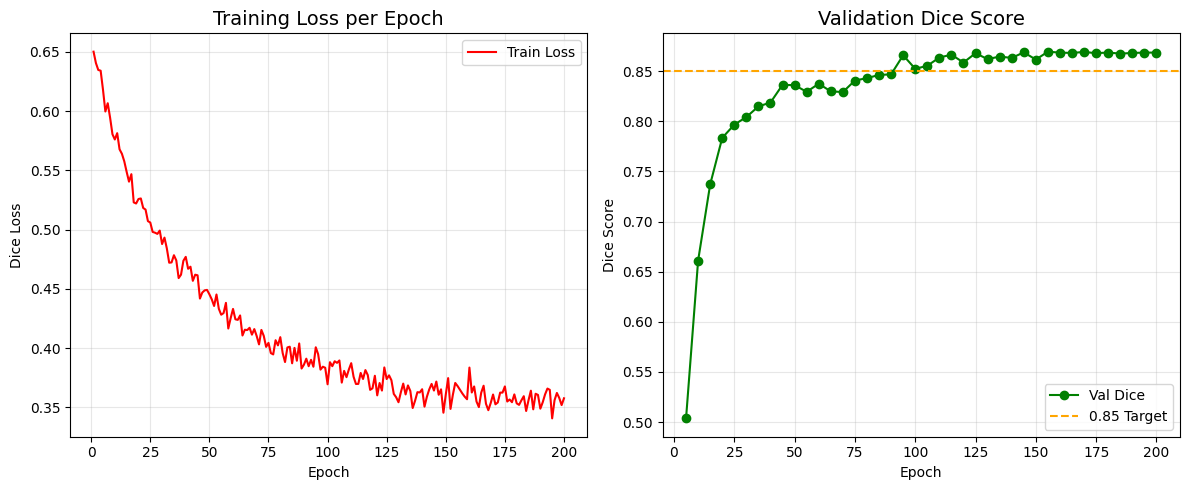


--- Baseline U-Net Test Results ---
Test Dice Score: 0.8925
Inference Time:  0.0976 sec/volume
Avg Calcium Included in Heart Mask: 99.90%




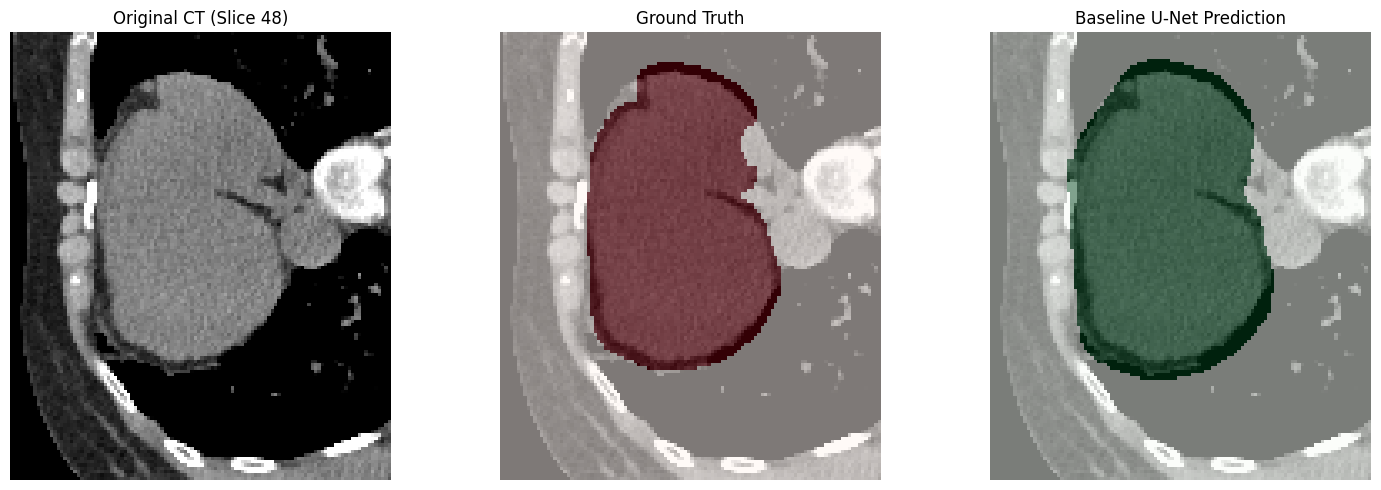

In [33]:
# ==============================================================================
#                      TRAIN & EVALUATE BASELINE U-NET
# ==============================================================================
print("\n========================================================")
print("--- LIGHTWEIGHT U-NET ---")
print("========================================================")

unet_model = UNet(
    spatial_dims=3, in_channels=1, out_channels=1,
    channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2),
    num_res_units=2, dropout=0.2
).to(DEVICE)

if torch.cuda.device_count() > 1: 
    unet_model = nn.DataParallel(unet_model)

if len(train_loader) > 0:
    train_model(unet_model, "/kaggle/working/unet_best.pth", epochs=EPOCHS)
    unet_dice, unet_time = evaluate_and_visualize(unet_model, "/kaggle/working/unet_best.pth", "Baseline U-Net")


--- SEGRESNET ---

--- Starting Training & Validation ---
Epoch 1/200 - Train Loss: 0.5652, LR: 0.000100
Epoch 5/200 - Train Loss: 0.4019, Val Dice: 0.7377, LR: 0.000100
  🌟 New Best Model! Saved at epoch 5
Epoch 10/200 - Train Loss: 0.3888, Val Dice: 0.7624, LR: 0.000099
  🌟 New Best Model! Saved at epoch 10
Epoch 15/200 - Train Loss: 0.3603, Val Dice: 0.8051, LR: 0.000099
  🌟 New Best Model! Saved at epoch 15
Epoch 20/200 - Train Loss: 0.3364, Val Dice: 0.8398, LR: 0.000098
  🌟 New Best Model! Saved at epoch 20
Epoch 25/200 - Train Loss: 0.3381, Val Dice: 0.8707, LR: 0.000096
  🌟 New Best Model! Saved at epoch 25
Epoch 30/200 - Train Loss: 0.3216, Val Dice: 0.8514, LR: 0.000095
Epoch 35/200 - Train Loss: 0.3097, Val Dice: 0.8838, LR: 0.000093
  🌟 New Best Model! Saved at epoch 35
Epoch 40/200 - Train Loss: 0.2861, Val Dice: 0.8788, LR: 0.000090
Epoch 45/200 - Train Loss: 0.2794, Val Dice: 0.8979, LR: 0.000088
  🌟 New Best Model! Saved at epoch 45
Epoch 50/200 - Train Loss: 0.2745, V

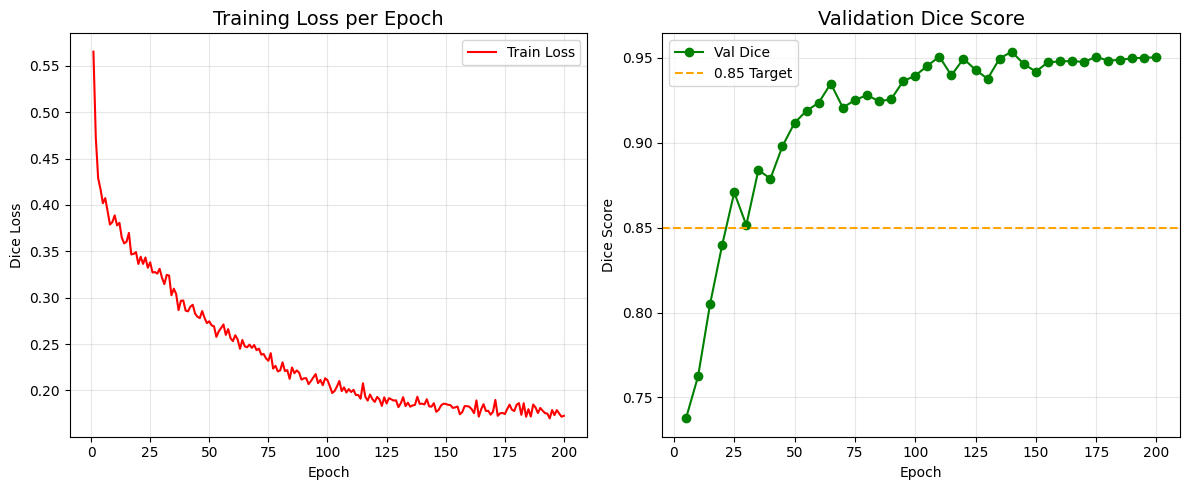


--- SegResNet Test Results ---
Test Dice Score: 0.9440
Inference Time:  0.0955 sec/volume
Avg Calcium Included in Heart Mask: 82.75%




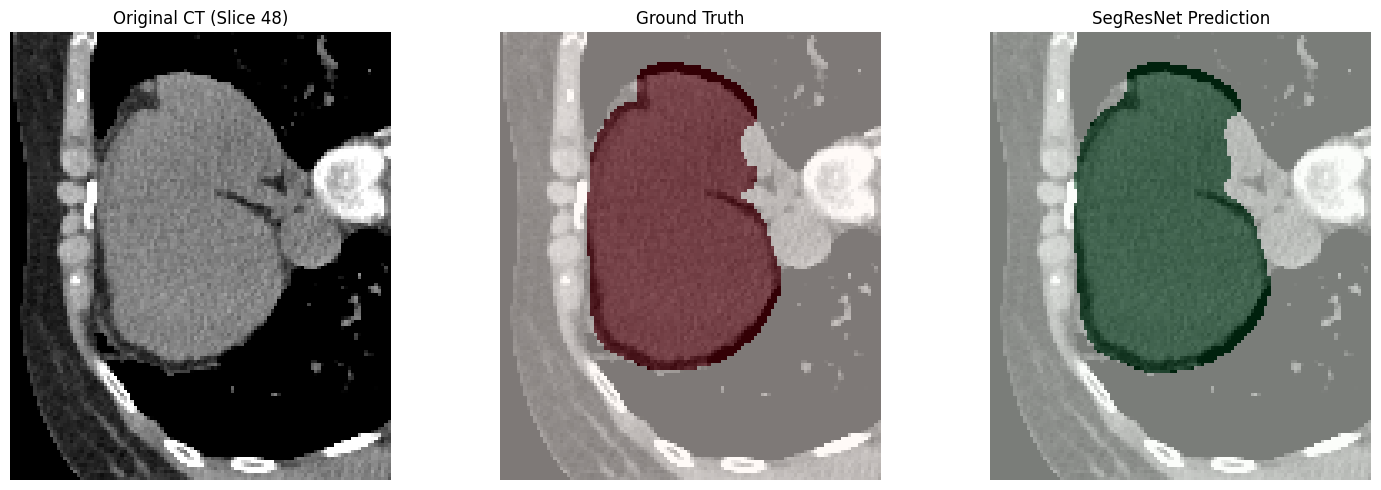

In [34]:
# ==============================================================================
#                 TRAIN & EVALUATE SEGRESNET
# ==============================================================================
print("\n========================================================")
print("--- SEGRESNET ---")
print("========================================================")

segresnet_model = SegResNet(
    spatial_dims=3, init_filters=16, in_channels=1, 
    out_channels=1, dropout_prob=0.2,
).to(DEVICE)

if torch.cuda.device_count() > 1: 
    segresnet_model = nn.DataParallel(segresnet_model)

if len(train_loader) > 0:
    train_model(segresnet_model, "/kaggle/working/segresnet_best.pth", epochs=EPOCHS)
    segresnet_dice, segresnet_time = evaluate_and_visualize(segresnet_model, "/kaggle/working/segresnet_best.pth", "SegResNet")

In [35]:
# ==============================================================================
#                       FINAL SPEEDUP COMPARISON
# ==============================================================================
print("\n========================================================")
print("--- FINAL SPEEDUP COMPARISON ---")
print("========================================================")

if len(test_loader) > 0:
    ts_times = []
    for batch_idx in range(len(test_files)):
        original_nifti_path = test_files[batch_idx]["image"]
        start = time.time()
        subprocess.run(
            ["TotalSegmentator", "-i", original_nifti_path, "-o", "/tmp/ts_dummy", "--roi_subset", "heart", "--fast"], 
            stdout=subprocess.DEVNULL, 
            stderr=subprocess.DEVNULL
        )
        ts_times.append(time.time() - start)
    avg_ts_time = np.mean(ts_times)

    print(f"Total Test Volumes Evaluated: {len(test_files)}\n")
    print(f"1. TotalSegmentator | Time: {avg_ts_time:.4f} sec/vol")
    print(f"2. Baseline U-Net   | Time: {unet_time:.4f} sec/vol | Speedup: {avg_ts_time/unet_time:.0f}x | Dice: {unet_dice:.4f}")
    print(f"3. SegResNet        | Time: {segresnet_time:.4f} sec/vol | Speedup: {avg_ts_time/segresnet_time:.0f}x | Dice: {segresnet_dice:.4f}")


--- FINAL SPEEDUP COMPARISON ---
Total Test Volumes Evaluated: 8

1. TotalSegmentator | Time: 33.5502 sec/vol
2. Baseline U-Net   | Time: 0.0976 sec/vol | Speedup: 344x | Dice: 0.8925
3. SegResNet        | Time: 0.0955 sec/vol | Speedup: 351x | Dice: 0.9440
